# Warp Sandbox: Sampling-Time Feature Warping for Deterministic k-Center

**Goal**: Test whether sampling-time feature warping can make deterministic Stage A k-center selection behave more like representative bulk-majority selection and less like tail/outlier selection.

**Scope**: Exploratory and diagnostic. Warps are used ONLY for sampling geometry, not for downstream prediction features.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, List, Optional
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import pdist, squareform

# Add project root for imports (notebook: cwd is typically warping/ or msk_analysis/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "warping" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Resolve parquet path (prefer full, fallback to no_meds)
for candidate in [
    Path("/Users/cat2510/my_projects/msk_analysis/msk_2017_18_full.parquet"),
    PROJECT_ROOT / "msk_2017_18_full.parquet",
    PROJECT_ROOT.parent / "msk_2017_18_full.parquet",
    PROJECT_ROOT / "msk_2017_18_no_meds.parquet",
]:
    if candidate.exists():
        PARQUET_PATH = candidate
        break
else:
    raise FileNotFoundError("Parquet not found. Place msk_2017_18_full.parquet in msk_analysis/.")
print(f"Using parquet: {PARQUET_PATH}")

SEED = 42
np.random.seed(SEED)

Using parquet: /Users/cat2510/my_projects/msk_analysis/msk_2017_18_full.parquet


## Load data

In [2]:
df = pd.read_parquet(PARQUET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns (first 30): {list(df.columns[:30])}")

Shape: (251110, 115)
Columns (first 30): ['ENROLID', 'has_Anemia', 'has_Atherosclerotic_Heart_Disease', 'has_Chronic_Pain', 'has_Depression_Anxiety', 'has_Gastroesophageal_Reflux_Disease', 'has_General_Health_Check', 'has_Hyperlipidemia', 'has_Hypertension', 'has_Long_term_Drug_Therapy', 'has_Obesity', 'has_Sleep_Apnea', 'has_Type_2_Diabetes', 'has_Vitamin_D_Deficiency', 'has_Arthropathies', 'has_Dorsopathies', 'has_Soft_tissue', 'has_Osteopathies', 'has_Other_MSK', 'annual_cost_2018_deflated', 'top_10_pct_cost_2018', 'top_5_pct_cost_2018', 'top_2_pct_cost_2018', '2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_cost_3month', '2017Q3_direct_msk_cost_3month']


## Target and stratified subsample

Target: `top_2_pct_cost_2018` (top 2% of annual_cost_2018_deflated = cases). Consistent with `scripts/msk_gower_target.py` and `precompute_msk_gower_distances.py`.

In [3]:
# Ensure target column exists (from msk_gower_target convention)
TARGET_COL = "top_2_pct_cost_2018"
COST_COL_2018 = "annual_cost_2018_deflated"
if TARGET_COL not in df.columns and COST_COL_2018 in df.columns:
    thresh = df[COST_COL_2018].quantile(0.98)
    df[TARGET_COL] = (df[COST_COL_2018] >= thresh).astype(int)
    print(f"Created {TARGET_COL}: threshold={thresh:.0f}")
elif TARGET_COL in df.columns:
    print(f"Using existing {TARGET_COL}")

print("Full dataset class balance:")
print(df[TARGET_COL].value_counts())
print(f"Minority prevalence: {df[TARGET_COL].mean():.4f}")

Using existing top_2_pct_cost_2018
Full dataset class balance:
top_2_pct_cost_2018
0    246259
1      4851
Name: count, dtype: int64
Minority prevalence: 0.0193


In [4]:
# Stratified subsample: 5,000 rows, preserve target distribution
SUBSAMPLE_SIZE = 8_000
# train_test_split returns (train, test): first array is the train_size subset
sub_idx, _ = train_test_split(
    df.index, train_size=SUBSAMPLE_SIZE, stratify=df[TARGET_COL], random_state=SEED
)
sub = df.loc[sub_idx].reset_index(drop=True)
assert len(sub) == SUBSAMPLE_SIZE, f"Expected {SUBSAMPLE_SIZE} rows, got {len(sub)}"

print("Subsample class balance:")
print(sub[TARGET_COL].value_counts())
print(f"Minority prevalence: {sub[TARGET_COL].mean():.4f}")


sub_ids = set(sub["ENROLID"].astype(np.int64))
holdout = df[~df["ENROLID"].astype(np.int64).isin(sub_ids)].reset_index(drop=True)
val_holdout, test_pd = train_test_split(
    holdout, test_size=0.7, stratify=holdout[TARGET_COL], random_state=SEED
)
print(f"Val set size: {len(val_holdout):,}, Test set size: {len(test_pd):,} (holdout from full df, original distribution)")


Subsample class balance:
top_2_pct_cost_2018
0    7845
1     155
Name: count, dtype: int64
Minority prevalence: 0.0194
Val set size: 72,933, Test set size: 170,177 (holdout from full df, original distribution)


## Feature selection

Pick 4 mixed-type features for sampling geometry. Inspect available columns and choose actual existing ones.

In [25]:
# Preferred features (cost/utilization 2017 + binary)
FEAT_COLS  = [
    "direct_msk_cost_annual",
    "msk_procedure_quarterly_range_2017",
    "msk_procedure_quarterly_kurtosis_2017",
    "has_Long_term_Drug_Therapy",
    'direct_msk_quarterly_max_2017', '2017Q4_msk_procedure_cost_3month',
    'direct_msk_quarterly_std_2017',
    "has_Anemia", "has_Arthropathies", "has_Long_term_Drug_Therapy",
    "has_Dorsopathies"
]

CAT_COLS = sub.select_dtypes(include=["object","category","string"]).columns.tolist()
BIN_COLS = [c for c in sub.columns if sub[c].nunique() <= 2 and c not in CAT_COLS and c not in ["ENROLID"] and "2018" not in c]
FEAT_COLS = [c for c in sub.columns if c not in BIN_COLS and c not in CAT_COLS and c not in ["ENROLID"] and "2018" not in c]
# Ensure we have at least 2 features
avail_cont = [c for c in sub.select_dtypes(include=[np.number]).columns 
              if c not in [TARGET_COL, COST_COL_2018, "ENROLID"] and "2018" not in c]
for c in avail_cont[:4]:
    if c not in FEAT_COLS and len(FEAT_COLS) < 4:
        FEAT_COLS.append(c)
        print(f"  Added from available: {c}")

FEAT_BINARY = [c for c in FEAT_COLS if sub[c].nunique() <= 2]
FEAT_CONT = [c for c in FEAT_COLS if c not in FEAT_BINARY]
print(f"\n{len(FEAT_COLS)} feature columns: {FEAT_COLS}")
print(f"  Continuous: {FEAT_CONT}")
print(f"  Binary: {FEAT_BINARY}")


50 feature columns: ['2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q3_comorbidity_only_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', '2017Q4_comorbidity_only_cost_3month', 'direct_msk_cost_annual', 'msk_procedure_cost_annual', 'comorbidity_only_cost_annual', 'direct_msk_cost_deriv_Q1_Q2_2017', 'direct_msk_cost_deriv_Q2_Q3_2017', 'direct_msk_cost_deriv_Q3_Q4_2017', 'direct_msk_total_increasing_quarters_2017', 'direct_msk_avg_quarterly_derivative_2017', 'direct_msk_quarterly_std_2017', 'direct_msk_quarterly_skewness_2017', 'direct_msk_quarterly_kurtosis_2017', 'direct_msk_quarterly_cv_2017', 'direct_msk_quarterly_max_2017', 'direct_msk_quarterly_min_2017', 'direct_msk_quarterly_range_2017', 'msk_procedure_cost_

## Warp definitions

All warps are fit on **majority rows only**. They transform features for sampling geometry only.

In [8]:
def apply_warp_raw_simple(X: np.ndarray, col_mask_binary: np.ndarray, fit_stats: dict) -> np.ndarray:
    """A. raw_simple: binary 0/1, continuous z-score or min-max. No aggressive tail control."""
    out = X.copy().astype(np.float64)
    for j in range(X.shape[1]):
        if col_mask_binary[j]:
            out[:, j] = np.clip(X[:, j], 0, 1)
        else:
            mu, sig = fit_stats["mean"][j], fit_stats["std"][j]
            if sig > 1e-10:
                out[:, j] = (X[:, j] - mu) / sig
            else:
                out[:, j] = 0.0
    return out.astype(np.float32)

def apply_warp_clipped_robust(X: np.ndarray, col_mask_binary: np.ndarray, fit_stats: dict) -> np.ndarray:
    """B. clipped_robust: binary unchanged; continuous clipped at p97.5, then median/IQR scaled."""
    out = X.copy().astype(np.float64)
    for j in range(X.shape[1]):
        if col_mask_binary[j]:
            out[:, j] = np.clip(X[:, j], 0, 1)
        else:
            lo, hi = fit_stats["clip_lo"][j], fit_stats["clip_hi"][j]
            med, iqr = fit_stats["median"][j], fit_stats["iqr"][j]
            clipped = np.clip(X[:, j], lo, hi)
            if iqr > 1e-10:
                out[:, j] = (clipped - med) / iqr
            else:
                out[:, j] = 0.0
    return out.astype(np.float32)

def apply_warp_log_clip(X: np.ndarray, col_mask_binary: np.ndarray, fit_stats: dict) -> np.ndarray:
    """C. log_clip: log1p for positive skewed, then clip, then robust-scale. Binary unchanged."""
    out = X.copy().astype(np.float64)
    for j in range(X.shape[1]):
        if col_mask_binary[j]:
            out[:, j] = np.clip(X[:, j], 0, 1)
        else:
            raw = np.maximum(X[:, j], 0)
            log_x = np.log1p(raw)
            lo, hi = fit_stats["log_clip_lo"][j], fit_stats["log_clip_hi"][j]
            med, iqr = fit_stats["log_median"][j], fit_stats["log_iqr"][j]
            clipped = np.clip(log_x, lo, hi)
            if iqr > 1e-10:
                out[:, j] = (clipped - med) / iqr
            else:
                out[:, j] = 0.0
    return out.astype(np.float32)

def apply_warp_bounded_rank(X: np.ndarray, col_mask_binary: np.ndarray, fit_stats: dict) -> np.ndarray:
    """D. bounded_rank: map to empirical CDF / percentile rank, clip [0.02, 0.98]. Binary unchanged."""
    out = X.copy().astype(np.float64)
    for j in range(X.shape[1]):
        if col_mask_binary[j]:
            out[:, j] = np.clip(X[:, j], 0, 1)
        else:
            ranks = fit_stats["rank_percentile"][j]
            r = np.interp(X[:, j], fit_stats["sorted_vals"][j], ranks)
            out[:, j] = np.clip(r, 0.025, 0.975) - 0.5  # center near 0
    return out.astype(np.float32)

In [9]:
def fit_warp_stats(X_maj: np.ndarray, col_mask_binary: np.ndarray) -> dict:
    """Compute fit statistics from majority rows for each warp."""
    stats = {}
    stats["mean"] = X_maj.mean(axis=0)
    stats["std"] = np.maximum(X_maj.std(axis=0), 1e-10)
    stats["median"] = np.median(X_maj, axis=0)
    q25 = np.percentile(X_maj, 25, axis=0)
    q75 = np.percentile(X_maj, 75, axis=0)
    stats["iqr"] = np.maximum(q75 - q25, 1e-10)
    stats["clip_lo"] = np.percentile(X_maj, 2, axis=0)
    stats["clip_hi"] = np.percentile(X_maj, 97.5, axis=0)
    # log_clip stats
    log_x = np.log1p(np.maximum(X_maj, 0))
    stats["log_clip_lo"] = np.percentile(log_x, 2, axis=0)
    stats["log_clip_hi"] = np.percentile(log_x, 97.5, axis=0)
    stats["log_median"] = np.median(log_x, axis=0)
    log_q25 = np.percentile(log_x, 25, axis=0)
    log_q75 = np.percentile(log_x, 75, axis=0)
    stats["log_iqr"] = np.maximum(log_q75 - log_q25, 1e-10)
    # bounded_rank
    stats["sorted_vals"] = [np.sort(X_maj[:, j]) for j in range(X_maj.shape[1])]
    stats["rank_percentile"] = [np.linspace(0, 1, len(X_maj)) for _ in range(X_maj.shape[1])]
    return stats

def farthest_first_kcenter_indices(d_nn: np.ndarray, M: int, seed_idx: int) -> List[int]:
    """Farthest-first k-center. d_nn: (n,n) distance matrix."""
    n = d_nn.shape[0]
    M = min(M, n)
    selected = [seed_idx]
    min_dist = np.array(d_nn[seed_idx, :], dtype=np.float32)
    min_dist[seed_idx] = -np.inf
    for _ in range(M - 1):
        nxt = int(np.argmax(min_dist))
        selected.append(nxt)
        row = np.array(d_nn[nxt, :], dtype=np.float32)
        min_dist = np.minimum(min_dist, row)
        min_dist[nxt] = -np.inf
    return selected

def choose_seed_centroid(X: np.ndarray) -> int:
    """Seed = point closest to centroid."""
    centroid = X.mean(axis=0)
    d = np.linalg.norm(X - centroid, axis=1)
    return int(np.argmin(d))

## Stage A sampling

For each warp: transform majority features, compute pairwise Euclidean distances, run farthest-first k-center. Also create random baseline.

In [10]:
maj = sub[sub[TARGET_COL] == 0].reset_index(drop=True)
min_df = sub[sub[TARGET_COL] == 1].reset_index(drop=True)
n_maj, n_min = len(maj), len(min_df)
print(f"Majority (controls): {n_maj}, Minority (cases): {n_min}")

# Row identifier: ENROLID if present, else index
ID_COL = "ENROLID" if "ENROLID" in maj.columns else None
if ID_COL:
    maj_ids = maj[ID_COL].values.astype(np.int64)
else:
    maj_ids = np.arange(n_maj, dtype=np.int64)
# Extract majority feature matrix (handle NaNs)
X_maj_raw = maj[FEAT_COLS].fillna(0).values.astype(np.float64)
col_mask_binary = np.array([c in FEAT_BINARY for c in FEAT_COLS])

# Fit stats on majority
fit_stats = fit_warp_stats(X_maj_raw, col_mask_binary)

# Warp variants
WARPS = {
    "raw_simple": lambda X: apply_warp_raw_simple(X, col_mask_binary, fit_stats),
    "clipped_robust": lambda X: apply_warp_clipped_robust(X, col_mask_binary, fit_stats),
    "log_clip": lambda X: apply_warp_log_clip(X, col_mask_binary, fit_stats),
    "bounded_rank": lambda X: apply_warp_bounded_rank(X, col_mask_binary, fit_stats),
}

# Light preprocessing for "original" space (used in density/atypicality diagnostics)
X_maj_light = apply_warp_raw_simple(X_maj_raw, col_mask_binary, fit_stats)



Majority (controls): 7845, Minority (cases): 155


## Stage A with candidate pool M (warps only)

Run k-center with M = 0.5 × n_majority for each warp (no random baseline). Use these M candidates for Stage B 1:1 matching.

In [12]:
# Candidate pool size M = 0.5 * n_majority (warps only)
M = int(0.5 * n_maj)
#M = n_min
results_M = {}

for name, warp_fn in WARPS.items():
    X_warp = warp_fn(X_maj_raw)
    d_mat = squareform(pdist(X_warp, metric="euclidean")).astype(np.float32)
    seed_idx = choose_seed_centroid(X_warp)
    sel_idx = farthest_first_kcenter_indices(d_mat, M, seed_idx)
    if name == "log_clip":
        results_M[name] = {"indices": sel_idx, "ids": maj_ids[sel_idx]}

print(f"Stage A with M={M} candidates (warps only):")
for name, r in results_M.items():
    print(f"  {name}: {len(r['indices'])} candidates")

Stage A with M=3922 candidates (warps only):
  log_clip: 3922 candidates


## Stage B: 1:1 matching on context features, custom gower method encoding as categoricals not one-hot

From each warp's M candidates, run min-cost 1:1 assignment using **context features** (demographics, region, plan, economic status). Uses `matching_ratio=1`, no case weights.

In [23]:
# Add parent path for public.two_stage_kcenter_match
if str(PROJECT_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.parent))
from public.two_stage_kcenter_match import solve_min_cost_assignment_adaptive_topk

# Context features (msk_feature_groups: demographics, region, plan, economic)
from scripts.msk_feature_groups import get_context_columns

cat_cols_sub = sub.select_dtypes(include=["object", "category", "string"]).columns.tolist()
CONTEXT_COLS = [c for c in sub.columns 
                    if any(p in c for p in ["AGEGRP", "SEX", "REGION", "EESTATU"])
                    and "2018" not in c and "ENROLID" not in c] + FEAT_COLS
if not CONTEXT_COLS:
    raise ValueError("No context columns found. Check msk_feature_groups or add AGEGRP/SEX/REGION/EESTATU.")
print(CONTEXT_COLS)
# Build numeric context matrix (categorical codes) — preserves ~0.12 mean cost scale
_ctx = sub[CONTEXT_COLS].copy()
for c in _ctx.columns:
    if _ctx[c].dtype in ["object", "category", "string"]:
        _ctx[c] = pd.Categorical(_ctx[c]).codes
X_ctx = _ctx.fillna(0).values.astype(np.float64)

maj_sub_pos = np.where(sub[TARGET_COL] == 0)[0]
min_sub_pos = np.where(sub[TARGET_COL] == 1)[0]
case_enrolids = min_df[ID_COL].values.astype(np.int64) if ID_COL else np.arange(n_min, dtype=np.int64)
X_cases = X_ctx[min_sub_pos]
assert X_cases.shape[0] == n_min



def gower_distances(X, Y, categorical_mask=None):
    """X (n,p), Y (m,p). Returns (n,m) cost matrix. Categorical: 0 if same, 1 if different. Continuous: |diff|/range."""
    n, p = X.shape
    m = Y.shape[0]
    if categorical_mask is None:
        categorical_mask = np.ones(p, dtype=bool)
    both = np.vstack([X, Y])
    ranges = np.nanmax(both, axis=0) - np.nanmin(both, axis=0)
    ranges = np.where(ranges > 1e-10, ranges, 1.0)
    cost = np.zeros((n, m), dtype=np.float32)
    for j in range(p):
        xj, yj = X[:, j:j+1], Y[:, j:j+1]
        if categorical_mask[j]:
            cost += (xj != yj.T).astype(np.float32)
        else:
            cost += np.abs(xj - yj.T).astype(np.float32) / ranges[j]
    cost /= p
    return cost

stage_B_results = {}
ctx_cat_mask = np.ones(X_ctx.shape[1], dtype=bool)
for name, r in results_M.items():
    cand_idx = r["indices"]
    X_ctrl = X_ctx[maj_sub_pos[cand_idx]]
    cost = gower_distances(X_cases, X_ctrl, categorical_mask=ctx_cat_mask)
    match_ctrl_local, match_costs = solve_min_cost_assignment_adaptive_topk(
        cost_matrix=cost,
        matching_ratio=1,
        case_weights=None,
    )
    cand_ids = r["ids"]
    selected_control_enrolids = cand_ids[match_ctrl_local]
    case_to_control = {
        int(ci): int(cj)
        for ci, cj in zip(case_enrolids, selected_control_enrolids)
    }
    stage_B_results[name] = {
        "case_to_control": case_to_control,
        "match_costs": match_costs,
        "mean_cost": float(match_costs.mean()),
    }
    print(f"  {name}: mean context-distance cost = {stage_B_results[name]['mean_cost']:.4f}")

['AGEGRP', 'SEX', 'REGION', 'EESTATU', '2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q3_comorbidity_only_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', '2017Q4_comorbidity_only_cost_3month', 'direct_msk_cost_annual', 'msk_procedure_cost_annual', 'comorbidity_only_cost_annual', 'direct_msk_cost_deriv_Q1_Q2_2017', 'direct_msk_cost_deriv_Q2_Q3_2017', 'direct_msk_cost_deriv_Q3_Q4_2017', 'direct_msk_total_increasing_quarters_2017', 'direct_msk_avg_quarterly_derivative_2017', 'direct_msk_quarterly_std_2017', 'direct_msk_quarterly_skewness_2017', 'direct_msk_quarterly_kurtosis_2017', 'direct_msk_quarterly_cv_2017', 'direct_msk_quarterly_max_2017', 'direct_msk_quarterly_min_2017', 'direct_msk_quarterly_range_2017', 'ms

## OCT evaluation: Stage B matched vs random

Verify each Stage B method selected exactly n_min controls, add random undersampling baseline (n_min controls), then train and compare OCTs on each set.

In [27]:
SEED

42

In [26]:
# Verify each method has n_min majority samples (1:1 matching)
for name, r in stage_B_results.items():
    n_ctrl = len(set(r["case_to_control"].values()))
    assert n_ctrl == n_min, f"{name}: expected {n_min} controls, got {n_ctrl}"
print(f"✓ All Stage B methods have {n_min} matched controls (1:1)")

# Add random undersampling baseline: n_min controls randomly selected from maj
rng = np.random.RandomState(SEED)
rnd_idx = rng.choice(n_maj, size=n_min, replace=False)
rnd_control_enrolids = maj_ids[rnd_idx]
stage_B_results_eval = dict(stage_B_results)
stage_B_results_eval["random"] = {
    "case_to_control": {int(ci): int(cj) for ci, cj in zip(case_enrolids, rnd_control_enrolids)},
    "match_costs": None,
    "mean_cost": np.nan,
}

# Build train sets: matched controls + min_df for each method
if str(PROJECT_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.parent))
from public.model_IAI import (
    finetune_oct,
    evaluate_binary_oct,
    get_bin_flag_columns,
    get_cat_columns,
    get_true_num_columns,
)

exclude_cols = ["ENROLID", TARGET_COL] + [c for c in sub.columns if "2018" in c]
oct_feature_cols = [c for c in sub.columns if c not in exclude_cols]
BIN_COLS = [c for c in get_bin_flag_columns(sub) if c in sub.columns]
CAT_COLS = [c for c in get_cat_columns(sub) if c in sub.columns]
NUM_COLS = [c for c in get_true_num_columns(sub, CAT_COLS, BIN_COLS) if c in sub.columns]
oct_feature_cols = [c for c in oct_feature_cols if c in BIN_COLS or c in CAT_COLS or c in NUM_COLS]
cat_cols = [c for c in CAT_COLS if c in oct_feature_cols]
num_cols = [c for c in NUM_COLS if c in oct_feature_cols]
bin_cols = [c for c in BIN_COLS if c in oct_feature_cols]
assert len(oct_feature_cols) >= 2, "Need at least 2 OCT features"

X_val_holdout = val_holdout[oct_feature_cols]
y_val_holdout = val_holdout[TARGET_COL]

X_test = test_pd[oct_feature_cols]
y_test = test_pd[TARGET_COL]


OCT_DEPTHS = [5, 7]
OCT_MINBUCKETS = [30]
OCT_CPS = [1e-3]

oct_metrics_stageB = []
for name, r in stage_B_results_eval.items():
    ctrl_enrolids = list(set(r["case_to_control"].values()))
    sel_maj = maj[maj[ID_COL].astype(np.int64).isin(ctrl_enrolids)].reset_index(drop=True)
    assert len(sel_maj) == n_min, f"{name}: expected {n_min} controls in maj subset, got {len(sel_maj)}"
    train_df = pd.concat([sel_maj, min_df], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    X_train = train_df[oct_feature_cols]
    y_train = train_df[TARGET_COL]

    try:
        model, params, _, preprocessor, feat_names = finetune_oct(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val_holdout,
            y_val=y_val_holdout,
            categorical_cols=cat_cols,
            numeric_cols=num_cols,
            binary_cols=bin_cols,
            depths=OCT_DEPTHS,
            minbuckets=OCT_MINBUCKETS,
            cps=OCT_CPS,
            tree_kind="oct",
            verbose=False,
            random_seed=SEED,
        )
        print("Best params: ", params)
        metrics = evaluate_binary_oct(
            model, X_test, y_test, preprocessor, feat_names,
            X_val_df=X_val_holdout, y_val=y_val_holdout,
        )
        auc_v = metrics.get("auc", np.nan)
        pr_v = metrics.get("pr_auc", np.nan)
        oct_metrics_stageB.append({"method": name, "auc": auc_v, "pr_auc": pr_v})
        print(f"  {name}: AUC={auc_v:.4f} PR-AUC={pr_v:.4f}")
    except Exception as e:
        print(f"  {name}: FAILED - {e}")
        oct_metrics_stageB.append({"method": name, "auc": np.nan, "pr_auc": np.nan})

oct_summary_stageB = pd.DataFrame(oct_metrics_stageB)
print("\nOCT summary (Stage B matched + random):")
print(oct_summary_stageB.to_string(index=False))

✓ All Stage B methods have 155 matched controls (1:1)


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best params:  {'variant': 'oct', 'hyperplane_config': None, 'depth': 5, 'minbucket': 30, 'cp': 0.001}
Test dataset for OCT application: 170,177 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
Computing optimal thresholds on validation set (72,933 samples)


...

Best params:  {'variant': 'oct', 'hyperplane_config': None, 'depth': 7, 'minbucket': 30, 'cp': 0.001}
Test dataset for OCT application: 170,177 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
Computing optimal thresholds on validation set (72,933 samples)


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  Applied validation-set thresholds to test set for evaluation
AUC score: 0.647
PR-AUC (Average Precision): 0.041
Best MCC (test set, threshold from val): 0.111 @ threshold=0.797701
Sensitivity (Recall) @MCC*: 0.282
Specificity @MCC*: 0.930
Balanced (G-mean) recall (test set, threshold from val): 0.620
Balanced (G-mean) specificity (test set, threshold from val): 0.658
Recall @ specificity>=0.60: 0.620 (achieved spec=0.658, thr=0.721311)
Number of leaves: 6
  random: AUC=0.6471 PR-AUC=0.0409

OCT summary (Stage B matched + random):
  method      auc   pr_auc
log_clip 0.667988 0.034256
  random 0.647121 0.040929


## Optional downstream for k-center: Train OCT and evaluate

Train OCT on each method's train set (subsampled majority + full minority) and evaluate on held-out test.

In [34]:
# Add parent of PROJECT_ROOT for public imports
if str(PROJECT_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.parent))

from public.model_IAI import (
    finetune_oct,
    evaluate_binary_oct,
    get_bin_flag_columns,
    get_cat_columns,
    get_true_num_columns,
)
results = results_M

# Add random undersampling baseline: n_min controls randomly selected from maj
rng = np.random.RandomState(SEED)
rnd_idx = rng.choice(n_maj, size=n_min, replace=False)
rnd_control_enrolids = maj_ids[rnd_idx]
results["random"] = {"indices": rnd_idx, "ids": maj_ids[rnd_idx]}

# Feature columns for OCT (exclude target, ENROLID, 2018)
exclude_cols = ["ENROLID", TARGET_COL] + [c for c in sub.columns if "2018" in c]
oct_feature_cols = [c for c in sub.columns if c not in exclude_cols]
BIN_COLS = [c for c in get_bin_flag_columns(sub) if c in sub.columns]
CAT_COLS = [c for c in get_cat_columns(sub) if c in sub.columns]
NUM_COLS = [c for c in get_true_num_columns(sub, CAT_COLS, BIN_COLS) if c in sub.columns]
oct_feature_cols = [c for c in oct_feature_cols if c in BIN_COLS or c in CAT_COLS or c in NUM_COLS]
cat_cols = [c for c in CAT_COLS if c in oct_feature_cols]
num_cols = [c for c in NUM_COLS if c in oct_feature_cols]
bin_cols = [c for c in BIN_COLS if c in oct_feature_cols]
assert len(oct_feature_cols) >= 2, "Need at least 2 OCT features; check exclude_cols / column types"

# Test set: complement of sub in full df (holdout)
sub_ids = set(sub["ENROLID"].astype(np.int64))
holdout = df[~df["ENROLID"].astype(np.int64).isin(sub_ids)].reset_index(drop=True)
val_holdout, test_pd = train_test_split(
    holdout, test_size=0.7, stratify=holdout[TARGET_COL], random_state=SEED
)
X_val_holdout = val_holdout[oct_feature_cols]
y_val_holdout = val_holdout[TARGET_COL]
print(f"Val set size: {len(val_holdout):,}, Test set size: {len(test_pd):,} (holdout from full df, original distribution)")

# OCT hyperparams (smaller for sandbox train size ~k+n_min)
OCT_DEPTHS = [5,7]
OCT_MINBUCKETS = [30]
OCT_CPS = [1e-4]

# Train and evaluate for each method
oct_metrics = []
for name, r in results.items():
    sel_maj = maj.iloc[r["indices"]]
    train_df = pd.concat([sel_maj, min_df], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle

    X_train = train_df[oct_feature_cols]
    y_train = train_df[TARGET_COL]
    X_test = test_pd[oct_feature_cols]
    y_test = test_pd[TARGET_COL]

    try:
        model, params, _, preprocessor, feat_names = finetune_oct(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val_holdout,
            y_val=y_val_holdout,
            categorical_cols=cat_cols,
            numeric_cols=num_cols,
            binary_cols=bin_cols,
            depths=OCT_DEPTHS,
            minbuckets=OCT_MINBUCKETS,
            cps=OCT_CPS,
            tree_kind="oct",
            verbose=False,
            random_seed=SEED,
        )
        metrics = evaluate_binary_oct(
            model, X_test, y_test, preprocessor, feat_names,
            X_val_df=X_val_holdout, y_val=y_val_holdout,
        )
        auc_v = metrics.get("auc", np.nan)
        pr_v = metrics.get("pr_auc", np.nan)
        oct_metrics.append({"method": name, "auc": auc_v, "pr_auc": pr_v})
        print(f"  {name}: AUC={auc_v:.4f} PR-AUC={pr_v:.4f}")
    except Exception as e:
        print(f"  {name}: FAILED - {e}")
        oct_metrics.append({"method": name, "auc": np.nan, "pr_auc": np.nan})

oct_summary = pd.DataFrame(oct_metrics)
print("\nOCT summary:")
print(oct_summary.to_string(index=False))

Val set size: 72,933, Test set size: 170,177 (holdout from full df, original distribution)


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Test dataset for OCT application: 170,177 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
Computing optimal thresholds on validation set (72,933 samples)


...

Test dataset for OCT application: 170,177 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
Computing optimal thresholds on validation set (72,933 samples)


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  Applied validation-set thresholds to test set for evaluation
AUC score: 0.647
PR-AUC (Average Precision): 0.041
Best MCC (test set, threshold from val): 0.111 @ threshold=0.797701
Sensitivity (Recall) @MCC*: 0.282
Specificity @MCC*: 0.930
Balanced (G-mean) recall (test set, threshold from val): 0.620
Balanced (G-mean) specificity (test set, threshold from val): 0.658
Recall @ specificity>=0.60: 0.620 (achieved spec=0.658, thr=0.721311)
Number of leaves: 6
  random: AUC=0.6471 PR-AUC=0.0409

OCT summary:
        method      auc   pr_auc
    raw_simple 0.454097 0.018059
clipped_robust 0.448005 0.017962
      log_clip 0.543549 0.025219
  bounded_rank 0.456557 0.018774
        random 0.647121 0.040929


## Composition diagnostics

Compare selected subsets on cost and utilization distributions. Goal: check whether warps reduce enrichment for high-cost/high-utilization tails.

As I add features, I want log_clip to remain close to random on nuisance tail distributions, but still distinct from random in a favorable geometric way — namely, broader deterministic coverage of dense majority structure.

In [134]:
# Cost/utilization columns for diagnostics (use available)
diag_cols_1 = [COST_COL_2018, "direct_msk_cost_annual", "msk_procedure_cost_annual"]
diag_cols_2 = [
    "msk_procedure_quarterly_range_2017",
    "msk_procedure_quarterly_kurtosis_2017", "msk_procedure_quarterly_cv_2017",
   ]
diag_cols_3 = [ '2017Q4_msk_procedure_cost_3month',"2017Q4_direct_msk_cost_3month"]
diag_cols_4 = [ 'msk_procedure_quarterly_kurtosis_2017', "comorbidity_only_quarterly_kurtosis_2017",
    'direct_msk_quarterly_kurtosis_2017']
diag_cols_5 = [ 'has_Long_term_Drug_Therapy', "has_Anemia",
    'has_Arthropathies']
DIAG_COLS = diag_cols_5
print(f"Diagnostic columns: {DIAG_COLS}")

Diagnostic columns: ['has_Long_term_Drug_Therapy', 'has_Anemia', 'has_Arthropathies']


In [135]:
# Summary table: mean, median, p90, p95 for each selection
summary_rows = []
for name, r in results.items():
    sel_maj = maj.iloc[r["indices"]]
    for col in DIAG_COLS:
        if col not in sel_maj.columns:
            continue
        vals = sel_maj[col].dropna()
        full_vals = maj[col].dropna()
        summary_rows.append({
            "method": name,
            "column": col,
            "mean": vals.mean(),
            "median": vals.median(),
            "p90": vals.quantile(0.9),
            "p95": vals.quantile(0.95),
            "full_mean": full_vals.mean(),
            "full_median": full_vals.median(),
        })
sum_df = pd.DataFrame(summary_rows)
# Show relative to full majority
for col in DIAG_COLS:
    sub_sum = sum_df[sum_df["column"] == col]
    if len(sub_sum) == 0:
        continue
    full_m = sub_sum["full_mean"].iloc[0]
    print(f"\n{col} (full majority mean={full_m:.2f}):")
    print(sub_sum[["method", "mean", "median", "p90", "p95"]].to_string(index=False))


has_Long_term_Drug_Therapy (full majority mean=0.16):
        method     mean  median  p90  p95
    raw_simple 0.262755     0.0  1.0  1.0
clipped_robust 0.271684     0.0  1.0  1.0
      log_clip 0.243622     0.0  1.0  1.0
  bounded_rank 0.267857     0.0  1.0  1.0
        random 0.168367     0.0  1.0  1.0

has_Anemia (full majority mean=0.08):
        method     mean  median  p90  p95
    raw_simple 0.173469     0.0  1.0  1.0
clipped_robust 0.128827     0.0  1.0  1.0
      log_clip 0.125000     0.0  1.0  1.0
  bounded_rank 0.155612     0.0  1.0  1.0
        random 0.075255     0.0  0.0  1.0

has_Arthropathies (full majority mean=0.44):
        method     mean  median  p90  p95
    raw_simple 0.368622     0.0  1.0  1.0
clipped_robust 0.427296     0.0  1.0  1.0
      log_clip 0.367347     0.0  1.0  1.0
  bounded_rank 0.391582     0.0  1.0  1.0
        random 0.397959     0.0  1.0  1.0


/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_12167/3512935075.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True)
/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_12167/3512935075.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True)
/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_12167/3512935075.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, vert=True)


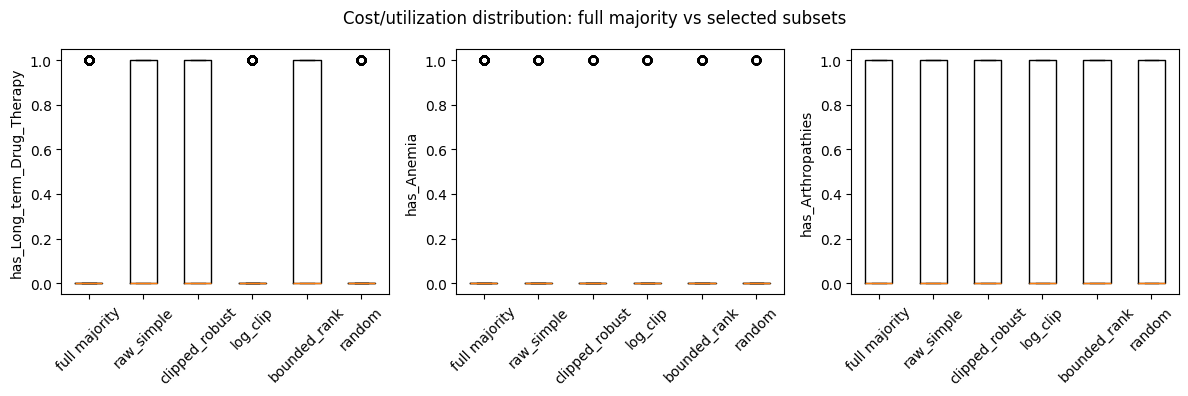

In [136]:
# Boxplots: cost distribution by selection method
if not DIAG_COLS:
    print("No diagnostic columns available; skipping boxplots.")
else:
    n_axes = min(len(DIAG_COLS), 3)
    fig, axes = plt.subplots(1, n_axes, figsize=(12, 4))
    if n_axes == 1:
        axes = [axes]
    for ax, col in zip(axes[:3], DIAG_COLS):
        if col not in maj.columns:
            continue
        data = [maj[col].values]
        labels = ["full majority"]
        for name, r in results.items():
            data.append(maj.iloc[r["indices"]][col].values)
            labels.append(name)
        ax.boxplot(data, labels=labels, vert=True)
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)
    plt.suptitle("Cost/utilization distribution: full majority vs selected subsets")
    plt.tight_layout()
    plt.show()

## Density / atypicality diagnostics

In the **original lightly normalized** feature space: distance to majority medoid and kNN density proxy. Compare selected subsets vs random.

In [137]:
# Original lightly normalized space
d_light = squareform(pdist(X_maj_light, metric="euclidean")).astype(np.float32)
medoid_idx = choose_seed_centroid(X_maj_light)
dist_to_medoid = d_light[medoid_idx, :]

# kNN density: avg distance to 10 nearest neighbors (higher = lower density)
k_nn = min(10, n_maj - 1)
sorted_d = np.sort(d_light, axis=1)
knn_avg_dist = sorted_d[:, 1 : k_nn + 1].mean(axis=1)

atyp_rows = []
for name, r in results.items():
    idx = r["indices"]
    atyp_rows.append({
        "method": name,
        "mean_dist_to_medoid": dist_to_medoid[idx].mean(),
        "median_dist_to_medoid": np.median(dist_to_medoid[idx]),
        "mean_knn_avg_dist": knn_avg_dist[idx].mean(),
        "median_knn_avg_dist": np.median(knn_avg_dist[idx]),
    })
# Full majority baseline
atyp_rows.append({
    "method": "full_majority",
    "mean_dist_to_medoid": dist_to_medoid.mean(),
    "median_dist_to_medoid": np.median(dist_to_medoid),
    "mean_knn_avg_dist": knn_avg_dist.mean(),
    "median_knn_avg_dist": np.median(knn_avg_dist),
})
atyp_df = pd.DataFrame(atyp_rows)
print("Atypicality in original lightly-normalized space:")
print(atyp_df.to_string(index=False))

Atypicality in original lightly-normalized space:
        method  mean_dist_to_medoid  median_dist_to_medoid  mean_knn_avg_dist  median_knn_avg_dist
    raw_simple            14.199395              11.703257           6.143384             4.210996
clipped_robust            10.152284               7.274893           4.584570             2.870414
      log_clip             8.003323               4.885318           3.253201             1.912233
  bounded_rank            10.628699               6.648954           4.555838             2.401335
        random             4.885736               3.619596           1.287513             0.685560
 full_majority             4.968405               3.601518           1.319193             0.714771


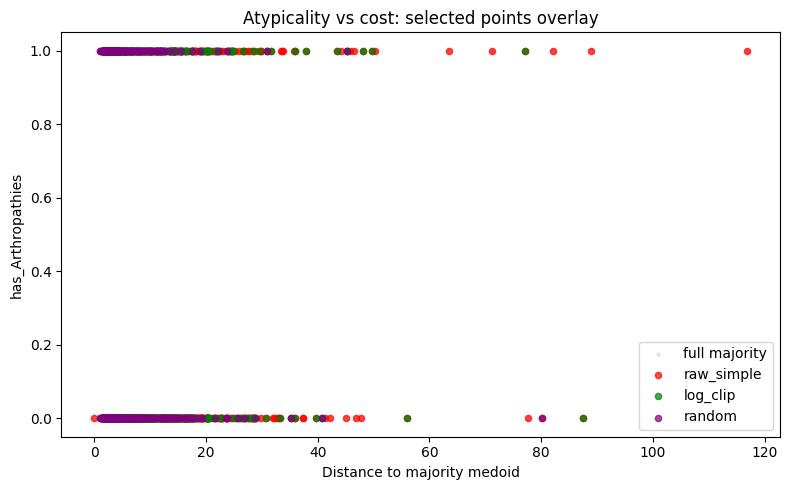

In [138]:
# Scatter: atypicality vs cost, colored by selection
cost_col = DIAG_COLS[2] if DIAG_COLS else (FEAT_CONT[0] if FEAT_CONT else FEAT_COLS[0])
cost_vals = maj[cost_col].values if cost_col in maj.columns else X_maj_raw[:, 0]

fig, ax = plt.subplots(figsize=(8, 5))
# Full majority as gray background
ax.scatter(dist_to_medoid, cost_vals, c="lightgray", s=5, alpha=0.5, label="full majority")
# Overlay selected points for each method
colors = {"raw_simple": "red", "clipped_robust": "blue", "log_clip": "green", "bounded_rank": "orange", "random": "purple"}
for name in ["raw_simple", "log_clip", "random"]:
    if name not in results:
        continue
    idx = results[name]["indices"]
    ax.scatter(dist_to_medoid[idx], cost_vals[idx], c=colors.get(name, "black"), s=20, alpha=0.7, label=name)
ax.set_xlabel("Distance to majority medoid")
ax.set_ylabel(cost_col)
ax.set_title("Atypicality vs cost: selected points overlay")
ax.legend()
plt.tight_layout()
plt.show()

## Geometry / cluster coverage diagnostics

Cluster majority in original lightly normalized space. Report how many clusters are represented and how balanced selected subsets are.

In [119]:
n_clusters = min(10, n_maj // 50)
km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
cluster_labels = km.fit_predict(X_maj_light)

cluster_rows = []
for name, r in results.items():
    idx = r["indices"]
    labs = cluster_labels[idx]
    unique, counts = np.unique(labs, return_counts=True)
    n_represented = len(unique)
    # Balance: std of counts (lower = more balanced)
    balance_std = counts.std() if len(counts) > 1 else 0
    cluster_rows.append({
        "method": name,
        "n_clusters_represented": n_represented,
        "balance_std": balance_std,
        "max_in_cluster": counts.max(),
        "min_in_cluster": counts.min(),
    })
cluster_df = pd.DataFrame(cluster_rows)
print("Cluster coverage:")
print(cluster_df.to_string(index=False))

Cluster coverage:
        method  n_clusters_represented  balance_std  max_in_cluster  min_in_cluster
    raw_simple                      10    39.194387             108               1
clipped_robust                       9    55.041623             186               1
      log_clip                       9    75.345296             262               1
  bounded_rank                      10    61.014752             216               1
        random                       9    85.838493             263               1
